# USGS vegetation library — `HyFourier` maps by instrument

Loads all Chapter V vegetation spectra from the USGS splib07b ASCII library, splits them by
**acquisition instrument** (wavelength sampling / band count), assigns **vegetation-family groups**
from `vegetation_families.csv`, builds one **`HyFourier` map per instrument** in a
**`FourierArchive`**, saves outputs under `sandbox/usgs_fourier_vegetation/`, and runs a test spectral search.

In [1]:
import os
import glob
import re
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import hylite
from hylite import io
from hylite import HyLibrary
from hylite.analyse.fourier import HyFourier, FourierArchive, FOURIER_ARCHIVE_EXTENSION

USGS_ROOT = '/Users/thiele67/Documents/data/Libraries/Spectra USGS/ASCIIdata_splib07b'
VEGETATION_DIR = os.path.join(USGS_ROOT, 'ChapterV_Vegetation')
FAMILIES_CSV = '/Users/thiele67/Documents/data/Libraries/Spectra USGS/vegetation_families.csv'
REPO_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(hylite.__file__)))
OUT_DIR = os.path.join(REPO_ROOT, 'sandbox', 'usgs_fourier_vegetation')
os.makedirs(OUT_DIR, exist_ok=True)

NAN_VALUE = -1.23e34

## 1. Wavelength grids and instrument order

Each USGS `.txt` spectrum uses one of the companion `*Wavelengths*.txt` files. We treat each
unique band count as an instrument and sort by covered wavelength range (shortest λ first).

In [2]:
# load wavelength axes (nm) keyed by band count
wav_by_n = {}
wav_label = {}
for path in glob.glob(os.path.join(USGS_ROOT, '*Wavelengths*.txt')):
    w = np.loadtxt(path, skiprows=1, dtype=np.float64) * 1000.0
    wav_by_n[len(w)] = w
    wav_label[len(w)] = os.path.basename(path)

def instrument_key(n_bands):
    label = wav_label[n_bands].lower()
    if 'beck' in label:
        return 'beck'
    if 'asdf' in label:
        return 'asdf'
    if 'aviris' in label:
        return 'aviris'
    if 'nic4' in label:
        return 'nic4'
    return f'n{n_bands}'


def make_instrument(n_bands):
    w = wav_by_n[n_bands]
    return {
        'key': instrument_key(n_bands),
        'n_bands': n_bands,
        'wav': w,
        'label': wav_label[n_bands],
        'range_nm': (float(w[0]), float(w[-1])),
    }

## 2. Vegetation families

In [3]:
families = {}
with open(FAMILIES_CSV, 'r') as f:
    for line in f:
        line = line.strip()
        if not line or ',' not in line:
            continue
        species, family = line.split(',', 1)
        families[species.strip().lower()] = family.strip().lower()

print(f'Loaded {len(families)} species → family mappings')

Loaded 61 species → family mappings


## 3. Load spectra and assign to instruments

In [4]:
def species_from_filename(path):
    """USGS splib07b names are splib07b_<Species>_..."""
    return os.path.basename(path).split('_')[1].lower()


def load_usgs_spectrum(path):
    r = np.loadtxt(path, skiprows=1, dtype=np.float32)
    r[r == NAN_VALUE] = np.nan
    return r


# bucket file paths by band count (instrument wavelength grid)
paths_by_n = defaultdict(list)
for path in sorted(glob.glob(os.path.join(VEGETATION_DIR, '*.txt'))):
    n = len(load_usgs_spectrum(path))
    if n not in wav_by_n:
        raise ValueError(f'No wavelength file for {n} bands: {path}')
    paths_by_n[n].append(path)

# instruments present in Chapter V, sorted by wavelength coverage
INSTRUMENTS = [
    make_instrument(n_bands)
    for n_bands in sorted(paths_by_n.keys(), key=lambda n: wav_by_n[n][0])
]
for inst in INSTRUMENTS:
    inst['paths'] = paths_by_n[inst['n_bands']]

print('Instruments (sorted by minimum wavelength):')
for inst in INSTRUMENTS:
    print(f"  {inst['key']:6s}  n={inst['n_bands']:4d}  "
          f"{inst['range_nm'][0]:8.1f}-{inst['range_nm'][-1]:8.1f} nm  "
          f"{len(inst['paths'])} spectra")

Instruments (sorted by minimum wavelength):
  beck    n=3961     205.0-  2976.0 nm  29 spectra
  asdf    n=2151     350.0-  2500.0 nm  218 spectra
  aviris  n=2203     370.5-  2506.6 nm  39 spectra


## 4. Build `HyLibrary` groups and `HyFourier` maps per instrument

In [5]:
def feature_wavelength_range(inst):
    """Clip to VNIR/SWIR window supported by this instrument grid."""
    w = inst['wav']
    #lo = np.min(w)
    #hi = np.max(w)
    
    lo = max(400.0, float(w[0]))
    #swir = w[w <= 2500.0]
    hi = min(15000.0, float(w[-1]))
    print(lo,hi)
    return lo, hi


def build_instrument_library(inst):
    """Return HyLibrary with vegetation-family groups for one instrument."""
    names, spectra = [], []
    for path in inst['paths']:
        names.append(os.path.splitext(os.path.basename(path))[0])
        spectra.append(load_usgs_spectrum(path))
    data = np.stack(spectra, axis=0)[:, None, :]
    lib = HyLibrary(data, lab=names, wav=inst['wav'])

    # HyLibrary groups keyed by vegetation family
    group_ids = defaultdict(list)
    for i, path in enumerate(inst['paths']):
        species = species_from_filename(path)
        family = families.get(species, 'unclassified')
        group_ids[family].append(i)
    for family, ids in sorted(group_ids.items()):
        lib.add_group(family, ids)
    return lib


libraries = {}
archive = FourierArchive()
for inst in INSTRUMENTS:
    key = inst['key']
    print(f'Building {key} ...')
    lib = build_instrument_library(inst)
    libraries[key] = lib

    # SWIR-focused subset for feature mapping (respects each instrument's λ coverage)
    lo, hi = feature_wavelength_range(inst)
    subset = lib.export_bands((lo, hi))
    hf = HyFourier(subset, padding='cosine', max_freq=0.25, vb=True)
    hf.precomputeExtrema(kde_sigma=10.0, vb=True)
    archive[key] = hf
    print(f'  library: {lib.sample_count()} samples, groups: {len(lib.get_groups())}')
    print(f'  HyFourier ({lo:.0f}-{hi:.0f} nm): {hf.data.shape}')

Building beck ...
400.0 2976.0000999999997


  library: 29 samples, groups: 6
  HyFourier (400-2976 nm): (29, 845, 2)
Building asdf ...
400.0 2500.0


  library: 218 samples, groups: 9
  HyFourier (400-2500 nm): (218, 525, 2)
Building aviris ...
400.0 2506.5998999999997


  library: 39 samples, groups: 7
  HyFourier (400-2507 nm): (39, 543, 2)


## 5. Save libraries and Fourier maps

In [6]:
FDA_PATH = os.path.join(OUT_DIR, 'usgs_vegetation')
archive.save(FDA_PATH)
print('Saved', FDA_PATH + FOURIER_ARCHIVE_EXTENSION)

Saved /Users/thiele67/Documents/python/hylite/sandbox/usgs_fourier_vegetation/usgs_vegetation.fda


## 6. Test query — red-edge absorption near 760 nm

Uses `HyFourier.search()` naive-Bayes ranking for a chlorophyll red-edge minimum.

In [7]:
archive = FourierArchive.load(os.path.join(OUT_DIR, 'usgs_vegetation'))
print('Loaded instruments:', list(archive.keys()))


Loaded instruments: ['beck', 'asdf', 'aviris']


  0.0447 (beck) [grass] splib07b_LawnGrass_GDS91b_-shiftd_3nm_BECKa_AREF
  0.0265 (beck) [grass] splib07b_Grass_dry.83+.17NaMont_AMX35_BECKb_AREF
  0.0257 (beck) [grass] splib07b_Cheatgrass_ANP92-11A_BECKa_AREF
  0.0189 (aviris) [microbial] splib07b_Bacterial_mat_YNP-B1_AVIRISb_RTGC
  0.0149 (asdf) [rangeland] splib07b_Rangeland_L02-023_S01%_G56%_ASDFRa_AREF
  0.0126 (beck) [forb] splib07b_Tumbleweed_ANP92-2C_Dry_BECKa_AREF
  0.0106 (beck) [grass] splib07b_LawnGrass_GDS91b_+1shf-unshf_BECKa_AREF
  0.0084 (beck) [shrub] splib07b_Sagebrush_IH91-1B_BECKa_AREF
  0.0076 (beck) [grass] splib07b_Grass_dry.9+.1green_AMX32_BECKa_AREF
  0.0071 (beck) [shrub] splib07b_Rabbitbrush_ANP92-27_BECKa_AREF
  0.0064 (beck) [shrub] splib07b_Saltbrush_ANP92-31A_BECKa_AREF
  0.0053 (beck) [grass] splib07b_Grass_dry.8+.2green_AMX31_BECKa_AREF
  0.0051 (beck) [shrub] splib07b_Blackbrush_ANP92-9A_leaves_BECKa_AREF
  0.0050 (asdf) [wetland] splib07b_Marsh_water_CRMS121v69-glint_ASDFRa_AREF
  0.0042 (beck) [coni

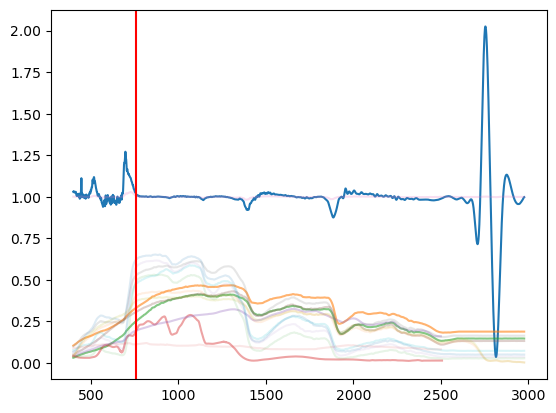

In [8]:
w = 760.
QUERY = str(w)
CONFIDENCE = 20.0
N_RESULT = 15

names, scores = archive.search(QUERY, confidence=CONFIDENCE, n_result=N_RESULT)
for name, score in zip(names, scores):
    print(f'  {score:6.4f} {name}')
    
# plot the top match
for name, score in zip(names, scores):
    spectra = archive.getSpectra(name)
    plt.plot(spectra.get_wavelengths(), spectra.data[0,0,:], alpha=score / scores[0])
plt.axvline(w, color='r')
plt.show()

In [9]:
QUERY = 'grass' # n.b. amphibole should be included as a group key
CONFIDENCE = 20.0
N_RESULT = 15

for key in archive:
    names, scores = archive[key].search(QUERY, confidence=CONFIDENCE, n_result=N_RESULT)
    print(f'\n=== {key.upper()} — top matches for {QUERY!r} (±{CONFIDENCE} nm) ===')
    for name, score in zip(names, scores):
        print(f'  {score:6.4f} {name}')


=== BECK — top matches for 'grass' (±20.0 nm) ===
  1.0000 [grass] splib07b_LawnGrass_GDS91b_+1shft_3nm_BECKa_AREF
  1.0000 [grass] splib07b_Lawn_Grass_GDS91_green_BECKa_AREF
  1.0000 [grass] splib07b_Grass_dry.9+.1green_AMX32_BECKa_AREF
  1.0000 [grass] splib07b_Grass_dry.7+.3green_AMX30_BECKa_AREF
  1.0000 [grass] splib07b_LawnGrass_GDS91b_+1shf-unshf_BECKa_AREF
  1.0000 [grass] splib07b_Grass_dry.6+.4green_AMX29_BECKa_AREF
  1.0000 [grass] splib07b_LawnGrass_GDS91b_+const_1.0_BECKa_AREF
  1.0000 [grass] splib07b_LawnGrass_GDS91b_-shiftd_3nm_BECKa_AREF
  1.0000 [grass] splib07b_LawnGrass_GDS91b_shifted_3nm_BECKa_AREF
  1.0000 [grass] splib07b_Grass_dry.5+.5green_AMX28_BECKa_AREF
  1.0000 [grass] splib07b_Grass_dry.8+.2green_AMX31_BECKa_AREF
  1.0000 [grass] splib07b_Grass_dry.4+.6green_AMX27_BECKa_AREF
  1.0000 [grass] splib07b_Cheatgrass_ANP92-11A_BECKa_AREF
  1.0000 [mixture] splib07b_Stonwll_Ply+.1grnGrass_AMX33_BECKa_AREF
  1.0000 [mixture] splib07b_Stonwll_Ply+.2grnGrass_AMX34_

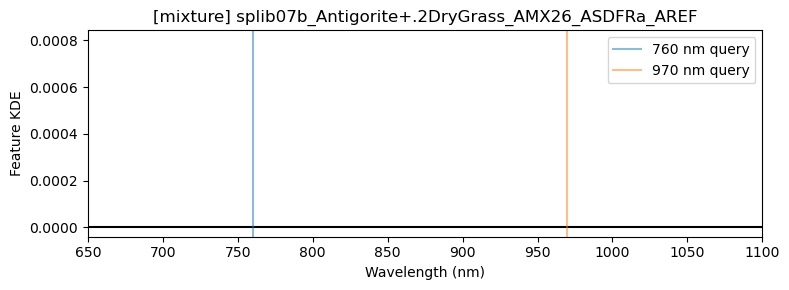

In [10]:
# optional: plot KDE match for the best ASDF hit
if 'asdf' in archive:
    hf = archive['asdf']
    names, scores = hf.search(QUERY, confidence=CONFIDENCE, n_result=1)
    from hylite.analyse.fourier import _sampleNames
    labels = _sampleNames(hf.header, hf.n_spectra, hf.original_shape, hf.spatial_shape)
    idx = labels.index(names[0])
    curve = hf.kde(2100, 2400, grid=True, index=idx)
    w = hf.get_wavelengths()
    plt.figure(figsize=(8, 3))
    plt.plot(w, curve, 'k-')
    plt.axvline(760, color='C0', alpha=0.5, label='760 nm query')
    plt.axvline(970, color='C1', alpha=0.5, label='970 nm query')
    plt.xlim(650, 1100)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Feature KDE')
    plt.title(names[0])
    plt.legend()
    plt.tight_layout()
    plt.show()